In [ ]:
import pandas as pd

df = pd.read_csv("tickets.csv")

print(df.columns)
df.head()

Index(['Document', 'Topic_group'], dtype='object')


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


clean text

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['Document'].apply(clean_text)
df.head()

,Document,Topic_group,clean_text
0,connection with icon icon dear please setup ic...,Hardware,connection with icon icon dear please setup ic...
1,work experience user work experience user hi w...,Access,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,Hardware,requesting for meeting requesting meeting hi p...
3,reset passwords for external accounts re expir...,Access,reset passwords for external accounts re expir...
4,mail verification warning hi has got attached ...,Miscellaneous,mail verification warning hi has got attached ...


TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['clean_text'])

Train Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

y = df['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.847930602006689
                       precision    recall  f1-score   support

               Access       0.92      0.87      0.90      1455
Administrative rights       0.87      0.69      0.77       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.79      0.88      0.84      2760
     Internal Project       0.91      0.79      0.85       451
        Miscellaneous       0.81      0.82      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.94      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.82      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



1. Priority Prediction

In [ ]:
priority_map = {
    'Hardware': 'High',
    'Storage': 'High',
    'Access': 'Medium',
    'Administrative rights': 'Medium',
    'Purchase': 'Medium',
    'HR Support': 'Low',
    'Internal Project': 'Low',
    'Miscellaneous': 'Low'
}

df['Priority'] = df['Topic_group'].map(priority_map)
df.head()

,Document,Topic_group,clean_text,Priority
0,connection with icon icon dear please setup ic...,Hardware,connection with icon icon dear please setup ic...,High
1,work experience user work experience user hi w...,Access,work experience user work experience user hi w...,Medium
2,requesting for meeting requesting meeting hi p...,Hardware,requesting for meeting requesting meeting hi p...,High
3,reset passwords for external accounts re expir...,Access,reset passwords for external accounts re expir...,Medium
4,mail verification warning hi has got attached ...,Miscellaneous,mail verification warning hi has got attached ...,Low


2.Train Priority Model

In [ ]:
y2 = df['Priority']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y2, test_size=0.2, random_state=42
)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2, y_train2)

pred2 = model2.predict(X_test2)

print("Priority Accuracy:", accuracy_score(y_test2, pred2))
print(classification_report(y_test2, pred2))

Priority Accuracy: 0.8779264214046822
              precision    recall  f1-score   support

        High       0.86      0.85      0.86      3316
         Low       0.87      0.91      0.89      3958
      Medium       0.92      0.85      0.88      2294

    accuracy                           0.88      9568
   macro avg       0.88      0.87      0.88      9568
weighted avg       0.88      0.88      0.88      9568



3. Real Prediction Demo

In [ ]:
sample = ["unable to login to my company account"]

sample_clean = clean_text(sample[0])

sample_vec = tfidf.transform([sample_clean])

print("Category:", model.predict(sample_vec))
print("Priority:", model2.predict(sample_vec))

Category: ['Access']
Priority: ['Medium']


Confusion Matrix

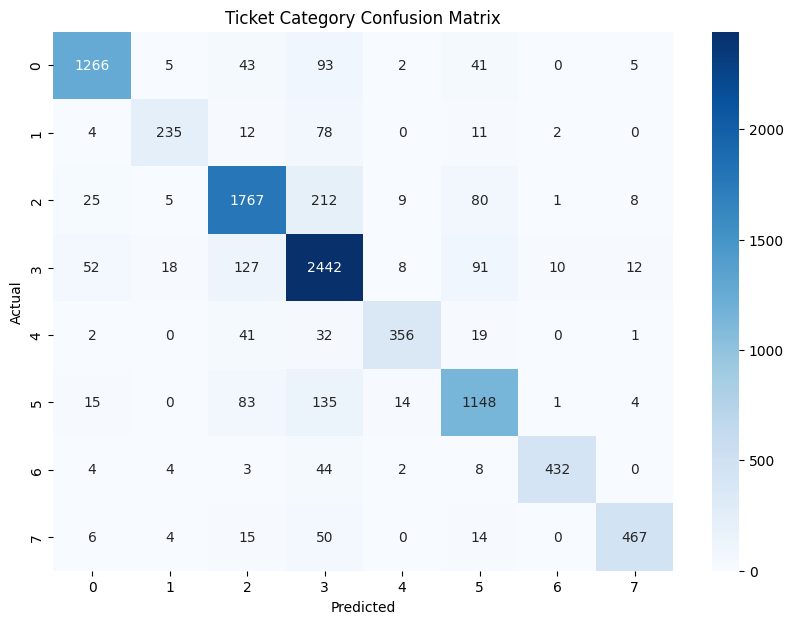

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Ticket Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Insights

- The Logistic Regression model achieved 84.79% accuracy for ticket category classification.
- Priority prediction model achieved 87% accuracy.
- Categories like Purchase and Storage performed strongly.
- The model can automate ticket routing and urgency detection.
- This helps reduce manual effort and improve response time.

## How the System Works

1. User submits support ticket text.
2. Text is cleaned using NLP preprocessing.
3. TF-IDF converts text into numerical features.
4. ML model predicts department/category.
5. Second model predicts urgency level (High / Medium / Low).
6. Ticket is routed to correct team quickly.

# Support Ticket Classification & Prioritization

Machine Learning project that automatically classifies support tickets into departments and predicts priority levels.

## Features
- Text Cleaning using NLP
- TF-IDF Vectorization
- Category Prediction
- Priority Prediction
- Accuracy Evaluation
- Confusion Matrix

## Results
- Category Accuracy: 84.79%
- Priority Accuracy: 87%

## Technologies
Python, Pandas, Scikit-learn, NLTK, Matplotlib, Seaborn